In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from catboost import CatBoostRegressor
# local imports
from modeling import build_prediction_dataset, temporal_split, evaluate_predictions

In [2]:
# Set paths to project folders
path_data = Path("../../1-Climate Finance Project")
# print(os.listdir(path_data))

# working directory analysis
wd_analysis = path_data / "Data" / "3-Analysis"

# Read data
analysis_df = pd.read_csv(wd_analysis / "Finance_Disaster_Analysis.csv")
analysis_df["month"] = pd.to_datetime(analysis_df["month"])

In [3]:
model_df = build_prediction_dataset(
    analysis_df,
    target_col="Early_Delinquency_Rate",
    horizon=1
)

train_df, valid_df, test_df = temporal_split(model_df, date_col="month", test_months=12, valid_months=12)

Train range: 2008-01-01 00:00:00 to 2023-02-01 00:00:00 | n = 64974
Valid range: 2023-03-01 00:00:00 to 2024-02-01 00:00:00 | n = 4284
Test range:  2024-03-01 00:00:00 to 2025-02-01 00:00:00 | n = 4284


In [4]:
categorical_cols = [
    "fips", "State", "County", "Coastal_County", "Coastline_Region", "month_num", "quarter"
]

feature_cols = [
    # static / slow-moving
    "fips", "State", "County", "Coastal_County", "Coastline_Region",
    "Land_Area", "Distance_To_Coast", "Pop",
    "month_num", "year", "quarter",

    # current disaster conditions
    "event_occur", "n_disasters", "log_total_damage",
    "flood_occur", "tornado_occur", "thunder_occur", "hail_occur",

    # lagged target information
    "Early_Delinquency_Rate_lag1", "Early_Delinquency_Rate_lag2",
    "Early_Delinquency_Rate_lag3", "Early_Delinquency_Rate_lag6",
    "Early_Delinquency_Rate_lag12",

    "Late_Delinquency_Rate_lag1", "Late_Delinquency_Rate_lag2",
    "Late_Delinquency_Rate_lag3", "Late_Delinquency_Rate_lag6",
    "Late_Delinquency_Rate_lag12",

    # lagged disasters
    "event_occur_lag1", "event_occur_lag2", "event_occur_lag3", "event_occur_lag6",
    "log_total_damage_lag1", "log_total_damage_lag2", "log_total_damage_lag3", "log_total_damage_lag6",
    "n_disasters_lag1", "n_disasters_lag2", "n_disasters_lag3", "n_disasters_lag6",
    "flood_occur_lag1", "flood_occur_lag2", "flood_occur_lag3", "flood_occur_lag6",
    "tornado_occur_lag1", "tornado_occur_lag2", "tornado_occur_lag3", "tornado_occur_lag6",
    "thunder_occur_lag1", "thunder_occur_lag2", "thunder_occur_lag3", "thunder_occur_lag6",
    "hail_occur_lag1", "hail_occur_lag2", "hail_occur_lag3", "hail_occur_lag6",

    # rolling exposure
    "event_occur_roll3", "event_occur_roll6",
    "log_total_damage_roll3", "log_total_damage_roll6",
]

# Keep only columns that actually exist
feature_cols = [c for c in feature_cols if c in model_df.columns]
categorical_cols = [c for c in categorical_cols if c in feature_cols]

X_train = train_df[feature_cols].copy()
y_train = train_df["target"].copy()

X_valid = valid_df[feature_cols].copy()
y_valid = valid_df["target"].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df["target"].copy()

print("Number of features:", len(feature_cols))

Number of features: 60


In [5]:


# Naive baseline: next month ~= current month
naive_pred = test_df["Early_Delinquency_Rate"].values
baseline_metrics = evaluate_predictions(y_test, naive_pred, name="Naive baseline")

Naive baseline
RMSE: 0.4279
MAE:  0.3266
R2:   0.7365
----------------------------------------


In [6]:
for col in categorical_cols:
    X_train[col] = X_train[col].astype(str)
    X_valid[col] = X_valid[col].astype(str)
    X_test[col] = X_test[col].astype(str)

cat_model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.03,
    depth=6,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=categorical_cols,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

0:	learn: 1.2901105	test: 1.1064729	best: 1.1064729 (0)	total: 191ms	remaining: 4m 46s
100:	learn: 0.3656997	test: 0.3539819	best: 0.3533419 (95)	total: 4.6s	remaining: 1m 3s
200:	learn: 0.3318749	test: 0.3220690	best: 0.3220690 (200)	total: 9.05s	remaining: 58.5s
300:	learn: 0.3229933	test: 0.3031110	best: 0.3031110 (300)	total: 13.5s	remaining: 53.6s
400:	learn: 0.3174173	test: 0.2952493	best: 0.2952493 (400)	total: 17.8s	remaining: 48.7s
500:	learn: 0.3130979	test: 0.2935086	best: 0.2931952 (482)	total: 22.1s	remaining: 44.1s
600:	learn: 0.3092816	test: 0.2922078	best: 0.2918497 (581)	total: 26.5s	remaining: 39.7s
700:	learn: 0.3058922	test: 0.2913328	best: 0.2911478 (666)	total: 30.8s	remaining: 35.2s
800:	learn: 0.3034883	test: 0.2908805	best: 0.2908470 (798)	total: 35.1s	remaining: 30.7s
900:	learn: 0.3013850	test: 0.2899780	best: 0.2899358 (897)	total: 39.5s	remaining: 26.2s
1000:	learn: 0.2993081	test: 0.2896162	best: 0.2894472 (967)	total: 43.8s	remaining: 21.8s
1100:	learn: 0

CatBoostRegressor(depth=6, eval_metric='RMSE', iterations=1500, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

In [7]:
valid_pred = cat_model.predict(X_valid)
test_pred = cat_model.predict(X_test)

valid_metrics = evaluate_predictions(y_valid, valid_pred, name="CatBoost validation")
test_metrics = evaluate_predictions(y_test, test_pred, name="CatBoost test")

CatBoost validation
RMSE: 0.2872
MAE:  0.2114
R2:   0.8536
----------------------------------------
CatBoost test
RMSE: 0.3398
MAE:  0.2486
R2:   0.8338
----------------------------------------


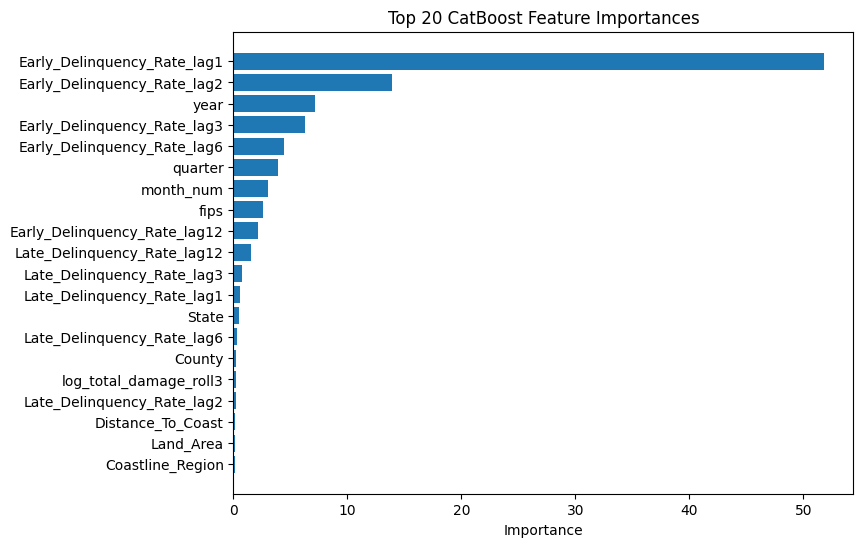

In [8]:
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": cat_model.get_feature_importance()
}).sort_values("importance", ascending=False)

top_imp = feature_importance.head(20).iloc[::-1]

plt.figure(figsize=(8, 6))
plt.barh(top_imp["feature"], top_imp["importance"])
plt.title("Top 20 CatBoost Feature Importances")
plt.xlabel("Importance")
plt.show()

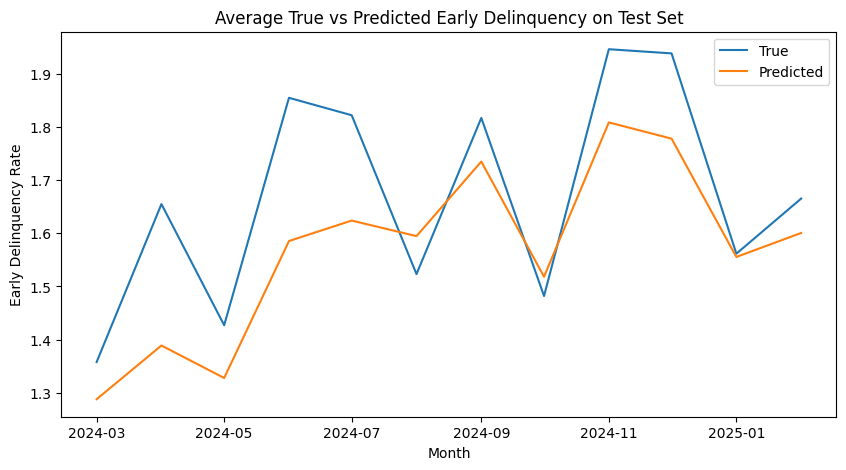

In [9]:
pred_df = test_df[["fips", "County", "month"]].copy()
pred_df["y_true"] = y_test.values
pred_df["y_pred"] = test_pred

monthly_perf = pred_df.groupby("month")[["y_true", "y_pred"]].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_perf.index, monthly_perf["y_true"], label="True")
plt.plot(monthly_perf.index, monthly_perf["y_pred"], label="Predicted")
plt.title("Average True vs Predicted Early Delinquency on Test Set")
plt.xlabel("Month")
plt.ylabel("Early Delinquency Rate")
plt.legend()
plt.show()